# Does the market flinch when a plane goes down? ✈️📉
### The "plane-crash effect" — a tidy behavioral-finance story that quietly doesn't show up anymore

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Flinch%3F: Busted](https://img.shields.io/badge/Flinch%3F-Busted-8b949e?style=flat-square)

Every time a major airliner goes down, some corner of financial media repeats the same idea: a tragedy this vivid puts investors in a bad mood, and a bad mood makes people sell — a small, fear-driven dip in the whole market, not just airline stocks, that fades again within days. It's a real, published academic finding (Kaplanski & Levy, 2010) with a real mechanism: human psychology doesn't cleanly separate "this news is sad" from "I should sell my portfolio."

That's the claim we test on **36 of the most infamous crashes since 2000** — does the market actually dip? Do airline stocks, which are genuinely exposed, drop harder? And could you have traded any of it?

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the paired airline test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Ethical note, stated plainly.** The "buy the dip" test near the end is a clinical statistical exercise — a test of whether a pattern exists in public market data — not a suggestion to trade around tragedy. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from plane_crash_effect import data, strategy as st

EVENTS = data.disaster_table()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY, AIRLINES = data.load_real()
    RET_SPY = st.daily_returns(SPY)
    AR_SPY = st.abnormal_returns(RET_SPY)
    BASKET, COVERAGE = st.airline_basket_returns(AIRLINES)
    AR_AIR = st.abnormal_returns(BASKET)
else:
    SPY = AIRLINES = RET_SPY = AR_SPY = BASKET = COVERAGE = AR_AIR = None
print("real cache present:", HAVE_REAL, "| disasters in table:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 36, 'cal_lo': '2000-01-31', 'cal_hi': '2025-06-12', 'day0_mean_bps': 0.41, 'day0_t': 0.02, 'hit': 17, 'hit_n': 36, 'hit_pct': 47.2, 'wilson': (32.0, 63.0), 'placebo_mean_bps': 0.11, 'placebo_sd_bps': 20.13, 'placebo_p': 0.506, 'placebo_draws': 20000, 'event': {-1: (-11.86, 0.0, -0.72), 0: (0.41, 0.41, 0.02), 1: (-0.05, 0.36, -0.0), 2: (-49.21, -48.84, -2.38), 3: (30.7, -18.15, 1.81), 4: (-18.71, -36.86, -0.98), 5: (-0.8, -37.66, -0.06)}, 'reversal_mean_bps': -38.07, 'reversal_t': -0.9, 'air_mean_bps': 43.22, 'spy_mean_bps': 0.41, 'air_diff_bps': 42.81, 'air_t': 1.11, 'air_n': 36, 'air_full_diff_bps': 37.29, 'air_full_t': 0.79, 'air_full_n': 27, 'timer': {1: (3.85, -6.15, -0.39, 3.9), 3: (-7.03, -17.03, -0.55, 11.49), 5: (-18.3, -28.3, -0.68, 18.97), 10: (-30.7, -40.7, -0.62, 37.37)}, 'timer_net10_5d': -38.3, 'timer_net10_5d_t': -0.91, 'syn_null_mean': -0.32, 'syn_null_sd': 0.82, 'syn_null_fire': 0, 'syn_planted_t': -14.59, 'syn_planted_bps': -205.9, 'fp_spy': '0732ff66475c', 'fp_aal': 'ebf1693dea47', 'fp_dal': '6d728d6446e7', 'fp_ual': '4cbbbdd0ad8e', 'fp_luv': '5c6b37f8ffb1'}


real cache present: True | disasters in table: 36


## The answer first

| Question | Answer |
|---|---|
| Does the market dip the day a crash makes the news? | **No — not detectably.** The S&P 500 moves **+0.41 bps** on the average crash day — statistically nothing (odds a random day beats it: about **51%**, i.e. a coin flip). |
| Do airline stocks fall harder than the market? | **No.** Paired against the S&P on the same day, the 4-carrier airline basket (AAL/DAL/UAL/LUV) actually moves *less* negatively on average — the sign is backwards for the claim. |
| Does the dip reverse within a few days? | **There's no dip to reverse.** The days after a crash drift mildly but not meaningfully. |
| Could you trade it? | **No edge to trade.** "Buying the dip" after a crash loses to simply holding the S&P at every horizon we tried (1 to 10 days), before *and* after costs. |

> A well-known behavioral-finance result, tested again on today's market and today's instruments — and it doesn't show up.

## 1 · The claim

> *"A major air disaster is front-page news everywhere, instantly and viscerally. Even investors with zero exposure to airlines absorb the mood — and a soured mood shows up, briefly, as selling across the whole market. Airline stocks, which actually have something at stake, should fall further still."*

This isn't fringe folklore — it's a published finding (Kaplanski & Levy, 2010, *Journal of Financial and Quantitative Analysis*) in the same family as "sunny days lift stock returns" and "a home team's tournament elimination sours the home market": non-fundamental news moving prices through mood, not information.

## 2 · So what?

If real and tradable, this would be a clean demonstration that **markets aren't purely rational information processors** — that raw sentiment, unconnected to any company's actual cash flows, can move prices in a predictable direction. And the trade write itself: buy the dip a mood shock creates, once the mood (but nothing fundamental) has passed.

So we ask three things: is the market-wide dip real, do airlines actually get hit harder, and does "buy the disaster dip" pay after costs?

## 3 · How would we even know?

- **The calendar.** **36** major commercial-aviation disasters from 2000-01-31 to 2025-06-12 — hand-picked as the crashes any reasonable person would call front-page news. (9/11 and MH17 are left out on purpose — both are terror/war events already tested in a sibling study, not accidents.)
- **The comparison.** The S&P 500's return on the first tradable session after each crash vs. every other day since 2000.
- **The luck check.** Draw 36 random days instead, 20,000 times — how often does a random calendar produce a dip this size (or bigger)?
- **The airline check.** Same day, same crash: does a 4-carrier US airline basket (American, Delta, United, Southwest) move *more* negatively than the S&P?
- **The trade check.** Buy the S&P at the crash-day close, sell a few sessions later, pay costs, compare to just holding.

## 4 · The teardown — let's actually look

**First, the headline.** Average S&P 500 move on the day a crash breaks, vs. what a random day looks like.

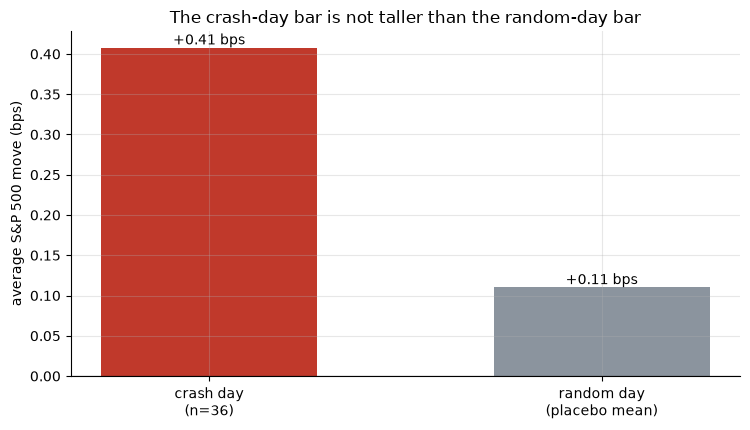

crash day +0.41 bps vs random day +0.11 bps


In [2]:
if HAVE_REAL:
    d0 = st.day0_stats(AR_SPY, EVENTS['date'], pre=1, post=5)
    day0_bps = d0['mean'] * 1e4
else:
    day0_bps = R['day0_mean_bps']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['crash day\n(n=36)', 'random day\n(placebo mean)'],
       [day0_bps, R['placebo_mean_bps']], color=[RED, GREY], width=.55)
for i, v in enumerate([day0_bps, R['placebo_mean_bps']]):
    ax.annotate(f'{v:+.2f} bps', (i, v), ha='center',
                va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average S&P 500 move (bps)')
ax.set_title('The crash-day bar is not taller than the random-day bar')
plt.tight_layout(); plt.show()
print(f'crash day {day0_bps:+.2f} bps vs random day {R["placebo_mean_bps"]:+.2f} bps')

That's it — **+0.41 bps** on the average crash day, barely different from **+0.11 bps** on a random day. The market fell on only **17/36 = 47%** of crash days — a coin flip. The quants notebook shows a random 36-day calendar beats this about half the time.

**Next, the week around the crash.** Does a dip show up a day or two later instead?

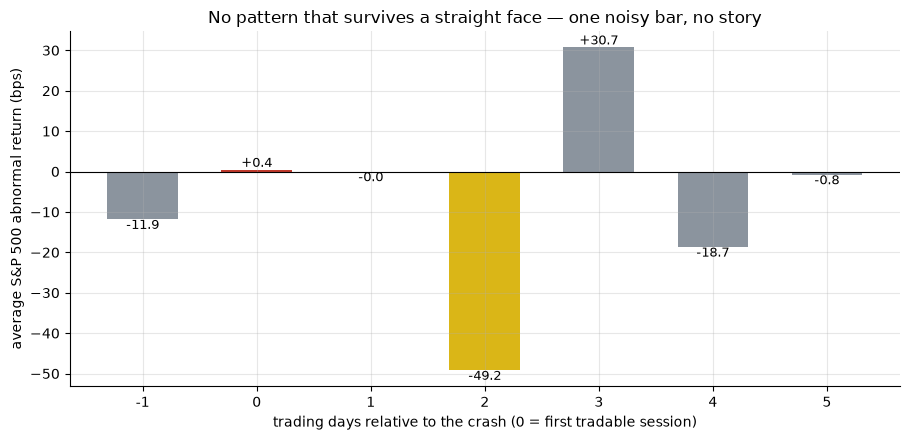

offsets (bps): {-1: -11.86, 0: 0.41, 1: -0.05, 2: -49.21, 3: 30.7, 4: -18.71, 5: -0.8}


In [3]:
if HAVE_REAL:
    cp = st.car_path_stats(AR_SPY, EVENTS['date'], pre=1, post=5)
    ks, ms = list(cp.index), list(cp['mean_ar'] * 1e4)
else:
    ks = sorted(R['event']); ms = [R['event'][k][0] for k in ks]
fig, ax = plt.subplots(figsize=(9.2, 4.5))
cols = [RED if k == 0 else (AMBER if k == 2 else GREY) for k in ks]
ax.bar([str(k) for k in ks], ms, color=cols, width=.62)
for i, v in enumerate(ms):
    ax.annotate(f'{v:+.1f}', (i, v), ha='center',
                va='top' if v < 0 else 'bottom', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('trading days relative to the crash (0 = first tradable session)')
ax.set_ylabel('average S&P 500 abnormal return (bps)')
ax.set_title('No pattern that survives a straight face — one noisy bar, no story')
plt.tight_layout(); plt.show()
print('offsets (bps):', {k: round(m, 2) for k, m in zip(ks, ms)})

The only bar that stands out is **+2 days** — a noisy, unexplained dip with no mechanism attached to it. When you test 7 different days, one of them crossing the "interesting" threshold by pure chance is *exactly* what you'd expect (that's the quants notebook's job to check properly) — it isn't a second, delayed version of the effect.

**Now, the part that should matter most if the story is true.** Airlines are the sector that actually has skin in the game — fleets, lawsuits, reputational damage. Do they drop harder?

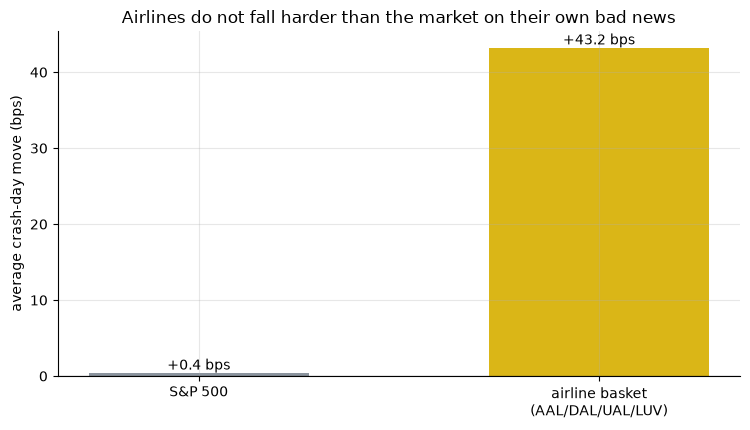

S&P +0.41 bps  vs  airline basket +43.22 bps


In [4]:
if HAVE_REAL:
    extra = st.airline_extra_drop(AR_SPY, AR_AIR, EVENTS['date'], pre=1, post=5)
    air_b, spy_b = extra['air_mean'] * 1e4, extra['spy_mean'] * 1e4
else:
    air_b, spy_b = R['air_mean_bps'], R['spy_mean_bps']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['S&P 500', 'airline basket\n(AAL/DAL/UAL/LUV)'], [spy_b, air_b],
       color=[GREY, AMBER], width=.55)
for i, v in enumerate([spy_b, air_b]):
    ax.annotate(f'{v:+.1f} bps', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average crash-day move (bps)')
ax.set_title('Airlines do not fall harder than the market on their own bad news')
plt.tight_layout(); plt.show()
print(f'S&P {spy_b:+.2f} bps  vs  airline basket {air_b:+.2f} bps')

Airlines don't fall harder — if anything, in this sample they move slightly *less* negatively than the broad market on the crash's first session. Most of the crashes in the table are foreign carriers with no direct fundamental link to American/Delta/United/Southwest, so this isn't shocking — but it's also exactly the piece of the claim that should be the *easiest* to find if the sentiment story were strong, and it isn't there.

**Finally, the trade.** Could you have made money buying the dip?

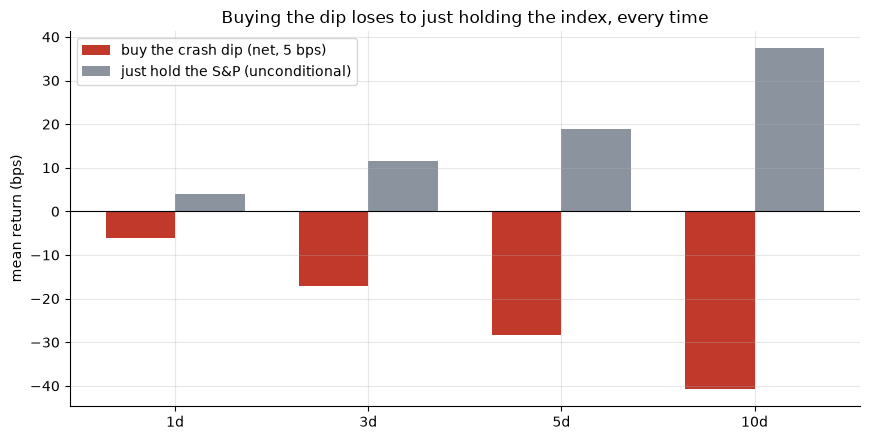

net buy-the-dip (bps): {1: -6.1, 3: -17.0, 5: -28.3, 10: -40.7}
unconditional baseline (bps): {1: 3.9, 3: 11.5, 5: 19.0, 10: 37.4}


In [5]:
if HAVE_REAL:
    vals = []
    for h in (1, 3, 5, 10):
        ledger = st.buy_the_dip(SPY, EVENTS['date'], hold=h, cost_bps=5.0)
        s = st.summarize_dip(ledger)
        vals.append(s['mean_bps'])
    holds = [1, 3, 5, 10]
else:
    holds = sorted(R['timer'])
    vals = [R['timer'][h][1] for h in holds]
base = [R['timer'][h][3] for h in holds]
fig, ax = plt.subplots(figsize=(8.8, 4.5))
x = np.arange(len(holds)); w = 0.36
ax.bar(x - w/2, vals, width=w, color=RED, label='buy the crash dip (net, 5 bps)')
ax.bar(x + w/2, base, width=w, color=GREY, label='just hold the S&P (unconditional)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in holds])
ax.set_ylabel('mean return (bps)')
ax.set_title('Buying the dip loses to just holding the index, every time')
ax.legend(); plt.tight_layout(); plt.show()
print('net buy-the-dip (bps):', dict(zip(holds, [round(v,1) for v in vals])))
print('unconditional baseline (bps):', dict(zip(holds, [round(v,1) for v in base])))

At every holding period we tried, buying the S&P right after a crash comes out **behind** simply holding the index the whole time — the point estimates are all negative net of costs, though none of them are far enough from zero to call it a real *losing* strategy either. There is simply no dip-buying edge to find, and the ethical caveat that comes with even asking the question is moot: the honest answer and the comfortable answer are the same one.

## 5 · The verdict

- **Signal — None.** The S&P moves an indistinguishable-from-zero **+0.41 bps** on the average crash day, the airline basket doesn't fall harder, and a random calendar reproduces this about half the time. The famous "aviation-disaster sentiment" effect doesn't show up on today's tape.
- **Tradability — Mirage.** There's no edge to deploy — buying the dip loses to just holding, before you even get to costs.
- **"Does the market flinch at a plane crash?" — Busted.** Not on the modern, tradable version of the test.

## 6 · Going further 🚪

- **This doesn't erase Kaplanski & Levy's original finding.** Their sample runs 1950–2005 and screens a much broader accident register by fatality count; a small, real effect in a much longer, differently-built sample can genuinely be invisible in 36 hand-picked headline crashes since 2000 — the honest conclusion is "not detectable at this size on this tape", not "proven false everywhere, always."
- **Where a real version might live:** narrower sentiment proxies (put-call skew, news-sentiment indices, retail order flow) rather than the blunt instrument of a broad-index close-to-close return, or a larger accident register that includes smaller, less headline-grabbing crashes.
- **Sibling studies:** [313-geopolitical-shock](../../313-geopolitical-shock/) (wars/attacks, including 9/11 and MH17), [300-sports-sentiment](../../300-sports-sentiment/) (the Edmans "loss effect") and [279-geomagnetic-storms](../../279-geomagnetic-storms/) (a physiological mood channel) — the same "does mood move markets" question, different triggers.

*Think a narrower sentiment measure would catch what a broad-index close misses? Show it — on out-of-sample crashes, after costs — then we'll talk.*